# Exercises

We have prepared five exercises in this chapter:

1. Modify the HCM code to work for three groups. This exercise can be divded into four tasks: 
    - modify the parameters,
    - modify the calculate_u function,
    - execute the clustering,
    - plot the results.
2. For density clustering, plot the feature space with all element marked with different color, depending on the cluster that it's assigned to. You should do the following tasks:
    - fill the get_color method,
    - fill the plot code.
3. Implement the Dunn index

## Libraries

To solve the exercises, we need the following libraries to load in the first place.


In [1]:
import numpy
import random
import numpy as np
import pandas as pd
from math import sqrt

import matplotlib.image as img
from PIL import Image

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from IPython.display import Image

In [2]:
# Dataset definitions for the exercises
# This file now runs without external pickle dependencies.
data_set = np.array([
    [0.007858546168958742, 0.12356687898089172],
    [0.01768172888015717, 0.18853503184713377],
    [0.01768172888015717, 0.2949044585987261],
    [0.15324165029469547, 0.0973248407643312],
    [0.17681728880157171, 0.12993630573248408],
    [0.09823182711198428, 0.2356687898089172],
    [0.9174852652259332, 0.9436305732484076],
    [1.0, 0.9681528662420382],
    [0.5697445972495089, 1.0],
    [0.4223968565815324, 0.385031847133758]
])

new_assignation_density = np.array([0, 0, 1, 1, -1, 2, 2, 2, 0, 1])

## Exercise 1: Modify the HCM code to work for three groups

The obvious part is the variable ```groups```, but the most changes needs to be done here:

In [3]:
### change here:
groups = 3

error_margin = 0.01
m=2
assignation=np.zeros((len(data_set),groups))

centers = np.array([[0.01229673, 0.25183492],
       [0.3689626 , 0.61904127],
       [0.95732769, 0.45059586]])

centers = np.array([[0.01229673, 0.25183492],
       [0.3689626 , 0.61904127],
       [0.95732769, 0.45059586]])

def calculate_distance(x,v):
    return sqrt((x[0]-v[0])**2+(x[1]-v[1])**2)

def calculate_new_centers(u):
    new_centers=[]
    for c in range(groups):
        u_x_vector=np.zeros(2)
        u_scalar=0.0
        for i in range(len(data_set)):
            u_scalar = u_scalar+(u[i][c]**m)
            u_x_vector=np.add(u_x_vector,np.multiply(u[i][c]**m,data_set[i]))
        new_centers.append(np.divide(u_x_vector,u_scalar))
    return new_centers

def calculate_differences(new_assignation, assignation):     
    return np.sum(np.abs(np.subtract(assignation,new_assignation)))

def cluster_hcm(assignation,centers):
    difference_limit_not_achieved=True
    new_centers = centers
    iter=0
    while difference_limit_not_achieved:
        new_assignation=[]
        for i in range(len(data_set)):
            new_assignation.append(calculate_u_three(data_set[i]))
        new_centers = calculate_new_centers(new_assignation)
        if iter>0:
            if calculate_differences(new_assignation, assignation) < error_margin:
                difference_limit_not_achieved=False
        assignation=new_assignation
        iter=iter+1
    return new_assignation, new_centers

### Modify the ``calculate_u`` function

Fill the gap below to make the function working for more groups than two. The goal here is to calculate the distance between ``x`` and the center of a given group and append the value to ``minimal_distance``.

In [4]:
def calculate_u_three(x):
    u_array = np.zeros(groups)
    minimal_distance = []
    for group in range(groups):
        minimal_distance.append(calculate_distance(x, centers[group]))
    min_group_id = np.argmin(minimal_distance)
    u_array[min_group_id] = 1
    return u_array

### Execute the clustering

As in the previous example we need to cluster it.

In [5]:
new_assignation_hcm3, new_centers_hcm3 = cluster_hcm(assignation, centers)
pd.DataFrame(new_centers_hcm3)

,0,1
0,0.078585,0.178323
1,0.496071,0.692516
2,0.958743,0.955892


### Plot the results

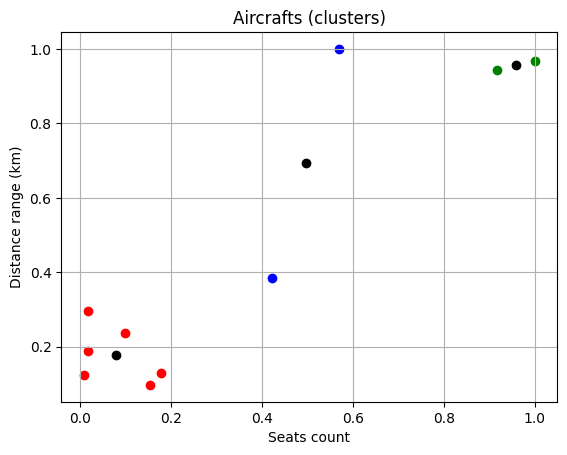

In [6]:
red = data_set[np.where(np.array(new_assignation_hcm3)[:,0]==1)]
blue = data_set[np.where(np.array(new_assignation_hcm3)[:,1]==1)]
green = data_set[np.where(np.array(new_assignation_hcm3)[:,2]==1)]

fig, ax = plt.subplots()

ax.scatter(blue[:,0],blue[:,1],c='blue')
ax.scatter(red[:,0],red[:,1],c='red')
ax.scatter(green[:,0],green[:,1],c='green')
ax.scatter(np.array(new_centers_hcm3)[:,0],np.array(new_centers_hcm3)[:,1],c='black')
ax.set(xlabel='Seats count', ylabel='Distance range (km)',
       title='Aircrafts (clusters)')
ax.grid()
plt.show()

## Exercise 2: Plot the density clusters

Use the code below to plot the results. You can play with the max_distance variable to get more or less groups.

In [7]:
# Using the inline dataset definitions from the first data cell.
# new_assignation_density is already defined above.

### Fill the ``get_group_objects`` method

Only one line needs to be updated. The ``get_group_objects`` function should return the objects of a given group.

In [8]:
colors = ['red','blue','green','orange','black','yellow']
    
def get_color(group_id):
    if group_id == -1:
        return 'gray'  # kolor dla noise
    else:
        return colors[group_id % len(colors)]
    
def get_group_objects(color_id):
    return data_set[np.where(np.array(new_assignation_density) == color_id)]

### Fill the plot code

If done properly the code below should return a plot of two clusters and the noise.

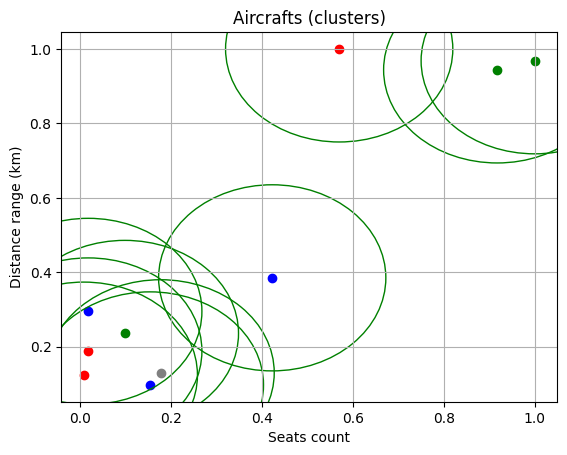

In [9]:
colors = ['red','blue','green','orange','black','yellow']

fig, ax = plt.subplots()

assigned_groups = new_assignation_density
for group in np.unique(assigned_groups):
    small_set = get_group_objects(group) 
    ax.scatter(small_set[:,0],small_set[:,1],c=get_color(group))
    for circle in small_set:
        circle1 = plt.Circle((circle[0],circle[1]), 0.25, color='green', fill=False)        
        ax.add_artist(circle1)
    
ax.set(xlabel='Seats count', ylabel='Distance range (km)',title='Aircrafts (clusters)')
ax.grid()
plt.show()

## Exercise 3: Implement the Dunn index:


In [10]:
def dunn_index(assignation, data_set):
    assignation = np.array(assignation)
    if assignation.ndim == 2:
        groups = np.argmax(assignation, axis=1)
    else:
        groups = assignation
    
    unique_groups = np.unique(groups)
    unique_groups = unique_groups[unique_groups != -1]
    
    if len(unique_groups) < 2:
        return float('inf') 
    
    diameters = []
    for g in unique_groups:
        points = data_set[np.array(groups) == g]
        if len(points) < 2:
            diameters.append(0)
        else:
            max_dist = 0
            for i in range(len(points)):
                for j in range(i+1, len(points)):
                    dist = calculate_distance(points[i], points[j])
                    if dist > max_dist:
                        max_dist = dist
            diameters.append(max_dist)
    
    max_diameter = max(diameters)
    
    inter_dists = []
    for i in range(len(unique_groups)):
        for j in range(i+1, len(unique_groups)):
            g1 = unique_groups[i]
            g2 = unique_groups[j]
            points1 = data_set[np.array(groups) == g1]
            points2 = data_set[np.array(groups) == g2]
            min_dist = float('inf')
            for p1 in points1:
                for p2 in points2:
                    dist = calculate_distance(p1, p2)
                    if dist < min_dist:
                        min_dist = dist
            inter_dists.append(min_dist)
    
    min_inter = min(inter_dists)
    
    return min_inter / max_diameter if max_diameter > 0 else float('inf')

Using data we used:

In [11]:
data_set = np.array([[0.007858546168958742, 0.12356687898089172], [0.01768172888015717, 0.18853503184713377], [0.01768172888015717, 0.2949044585987261], [0.15324165029469547, 0.0973248407643312], [0.17681728880157171, 0.12993630573248408], [0.09823182711198428, 0.2356687898089172], [0.9174852652259332, 0.9436305732484076], [1.0, 0.9681528662420382], [0.5697445972495089, 1.0], [0.4223968565815324, 0.385031847133758]])

new_assignation_hcm3 = np.array([[0., 1., 0.],[0., 1., 0.], [0., 1., 0.],[0., 1., 0.], [0., 1., 0.], [0., 1., 0.], [0., 0., 1.], [0., 0., 1.], [0., 0., 1.], [1., 0., 0.]])

calculate Dunn index:

In [12]:
dunn_index(new_assignation_hcm3, data_set)

0.820741951518254